# Linear Regession Model

## What is linear regression?

A basic supervised learning approach for modelling the connection between a dependent variable and one or more independent variables is called linear regression. By fitting a straight line that most accurately depicts the data, it forecasts continuous values.

It makes the assumption that the input and output have a linear connection and makes forecasts using a best-fit line frequently employed in predictive models, trend analysis, and forecasting (GeeksforGeeks, 2026)

# Importing python libraries

In [600]:
!pip install seaborn 

In [601]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
#This section is for building the model 
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression

In this section I am importing the metrics needed to gather my R squared and other pwerformance metrics

In [602]:
from sklearn.metrics import r2_score, mean_absolute_error

# Importing the dataset


The dataset comes from Kaggle formulated by Brett Lantz “Machine learning with R” https://www.kaggle.com/datasets/mirichoi0218/insurance , in this dataset we work with both numerical and categorical data there are no missing values in this dataset but there is categorical data that needs to be encoded so that the machine can use the information to predict the outcomes of the plots that were created. We have 7 columns and 1339 rows of data within the 7 columns provided in the dataset.

In [603]:
dataset = pd.read_csv('insurance.csv')
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [604]:
print(x)
print(y)

[[19 'female' 27.9 0 'yes' 'southwest']
 [18 'male' 33.77 1 'no' 'southeast']
 [28 'male' 33.0 3 'no' 'southeast']
 ...
 [18 'female' 36.85 0 'no' 'southeast']
 [21 'female' 25.8 0 'no' 'southwest']
 [61 'female' 29.07 0 'yes' 'northwest']]
[16884.924   1725.5523  4449.462  ...  1629.8335  2007.945  29141.3603]


The below is the information pulled to see the data

In [605]:
dataset.info()
print(dataset.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


### Cleaning the dataset

We are looking for duplicates and unique values

In [606]:
dataset.duplicated
cat_col = [col for col in dataset.columns if dataset[col].dtype == 'object']
num_col = [col for col in dataset.columns if dataset[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['sex', 'smoker', 'region']
Numerical columns: ['age', 'bmi', 'children', 'charges']


In [607]:
dataset[cat_col].nunique()

sex       2
smoker    2
region    4
dtype: int64

In [608]:
print(dataset.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## Encoding the data

In this section we will be encoding the independent variables which contain string values that can not be read in the linear regression format.
The encoder works in such a way that the categorical data that we have in the dataset is formatted into numerical format so that the machine can read the data clearly. A neural network called the encoder decoder model is employed in jobs where the input and output are sequences, frequently of varying durations. It is frequently used in fields including speech processing, translation, and summarisation. (GeeksforGeeks,2026)

In [609]:
# Correction for Block [405]
# Use drop_first=True to avoid the dummy variable trap
region_dummies = pd.get_dummies(dataset['region'], prefix='region', drop_first=True)

dataset['sex_encoded'] = le_sex.fit_transform(dataset['sex'])
dataset['smoker_encoded'] = le_smoker.fit_transform(dataset['smoker'])

# Properly concatenate and update the dataset
dataset = pd.concat([dataset, region_dummies], axis=1)
dataset = dataset.drop('region', axis=1)

# Corrected mapping print statements
print("Sex Mapping:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Smoker Mapping:", dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_))))

Sex Mapping: {'female': np.int64(0), 'male': np.int64(1)}
Smoker Mapping: {'no': np.int64(0), 'yes': np.int64(1)}


# Univariate analysis : The distribution plot

The most basic type of data analysis is univariate analysis. Since "uni" means "one," there is just one variable in your data. Its main goal is to describe; unlike regression, it does not address causes or links; It gathers data, condenses it, and looks for trends.

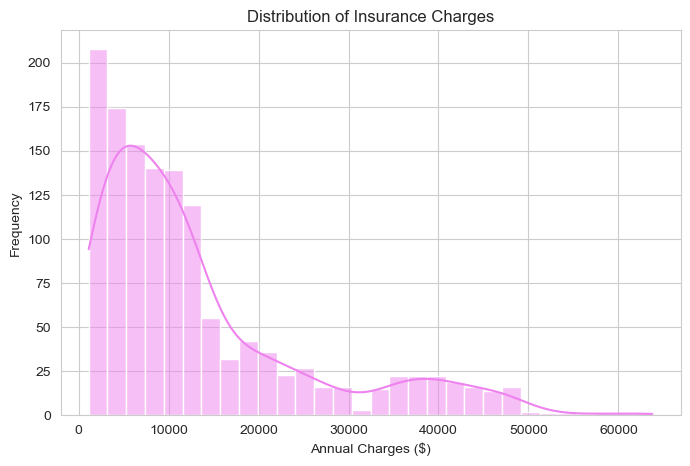

In [610]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

# Plotting the target variable
sns.histplot(dataset['charges'], kde=True, color='violet')

plt.title('Distribution of Charges')
plt.xlabel('Annual Charges ($)')
plt.ylabel('Frequency')
plt.show()

### Distribution of BMI

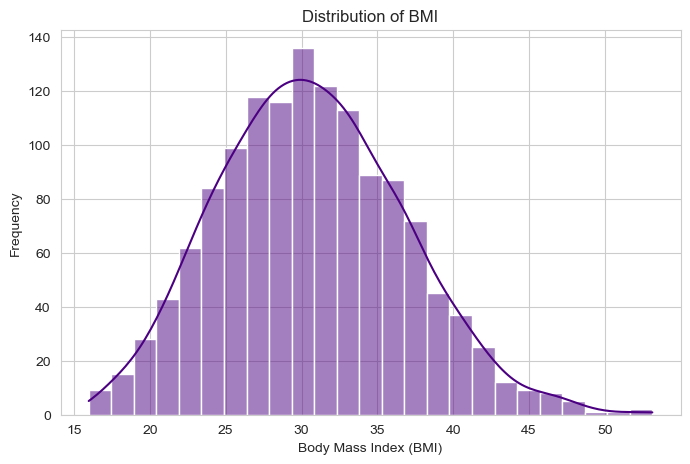

In [611]:
plt.figure(figsize=(8, 5))

# Plotting BMI
sns.histplot(dataset['bmi'], kde=True, color='indigo')

plt.title('Distribution of BMI')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')
plt.show()

### Distribution of Age

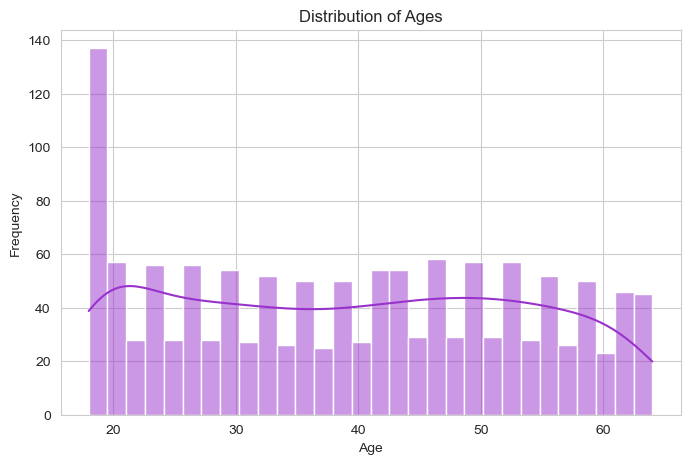

In [612]:
plt.figure(figsize=(8, 5))

# Plotting Age
sns.histplot(dataset['age'], bins=30, kde=True, color='darkorchid')

plt.title('Distribution of Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Detecting the ouliers based on the age

Data points that substantially differ from the rest of the dataset are known as outliers in machine learning, because they frequently distort statistical analysis and impair model performance.

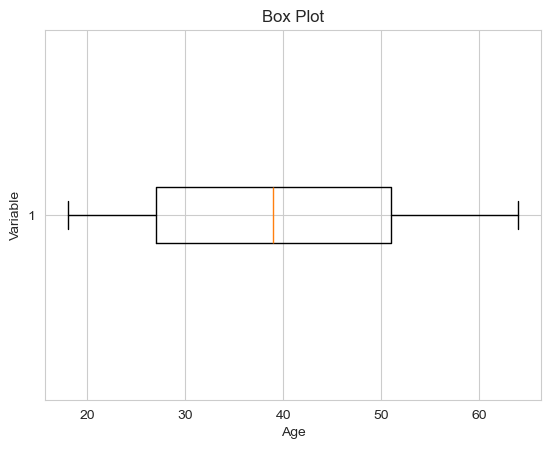

In [613]:
import matplotlib.pyplot as plt

plt.boxplot(dataset['age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

# Exploratory Data analysis through visualisation

In this step we will begin creasting the plots that will help our now completely numerical data be visualised so that we can analyse it further on the graphs
this will assist us in gaging the correlation of the charges based on the metrics of sex, age, BMI, if the individual has children if they smoke and finally the region the individual comes from that determines the way the data will skew in the case of the charges made on the medical insurance scheme.

Intercept: -11938.53857616715
Coefficients: [  256.85635254   339.19345361   475.50054515  -131.3143594
 23848.53454191  -352.96389942 -1035.02204939  -960.0509913 ]


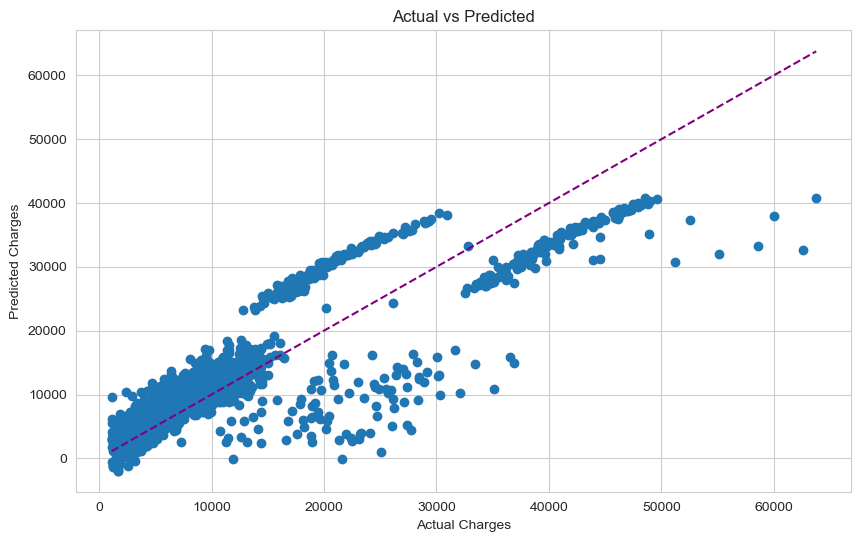

In [614]:
from sklearn.linear_model import LinearRegression

# Check if the region exists in the dataset before dropping
columns_to_drop = ['charges', 'sex', 'smoker']

# Adding region from the dataset
if 'region' in dataset.columns:
    columns_to_drop.append('region')

# Prepping the data for the scatter plot with the newly encoded columns
x = dataset.drop(columns=columns_to_drop)
y = dataset['charges'].values

# Creating the model for the linear regression
model = LinearRegression()
model.fit(x, y)

# previously has a myfunc label but it only works for none multi linear regression changed to prediction model
predictions = model.predict(x)

# creating the coeeficients for the regression model
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

 
# We plot Predicted vs Actual values to see accuracy of the dataset
plt.figure(figsize=(10, 6))
plt.scatter(y, predictions, color = 'pink', alpha = 0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='purple', linestyle='--') 
plt.scatter(y, predictions)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

# The Train-Test Split

In the previous step we created our scatter plot without the train-split test, The results will be visible after the split and after we encode again.

### Encoding the independant variable

In [615]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


x = dataset.drop(columns=['charges']).values 

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [1, 4, 5])
    ], 
    remainder='passthrough'
)

x = np.array(ct.fit_transform(x)).astype(float)

In [616]:
print(x)

[[1. 0. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 1. 0.]
 [0. 1. 1. ... 0. 1. 0.]
 ...
 [1. 0. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 0. 1.]
 [1. 0. 0. ... 1. 0. 0.]]


In [617]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Total rows: {len(x)}")
print(f"Training rows (80%): {len(x_train)}")
print(f"Testing rows (20%): {len(x_test)}")

Total rows: 1338
Training rows (80%): 1070
Testing rows (20%): 268


In [618]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit and transform the training data
x_train_scaled = scaler.fit_transform(x_train)

# transform the test data using the scaler fitted on training data
x_test_scaled = scaler.transform(x_test)

print("Scaling complete. Features are now between 0 and 1.")

Scaling complete. Features are now between 0 and 1.


In [619]:
print(x_train)

[[1. 0. 1. ... 1. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 ...
 [0. 1. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]]


In [620]:
print(x_test)

[[1. 0. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 ...
 [0. 1. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 0. 1.]]


In [621]:
print(y_train)

[ 9193.8385   8534.6718  27117.99378 ... 11931.12525 46113.511
 10214.636  ]


In [622]:
print(y_test)

[ 9095.06825   5272.1758   29330.98315   9301.89355  33750.2918
  4536.259     2117.33885  14210.53595   3732.6251   10264.4421
 18259.216     7256.7231    3947.4131   46151.1245   48673.5588
 44202.6536    9800.8882   42969.8527    8233.0975   21774.32215
  5080.096     7441.501     1256.299     2755.02095  11085.5868
 10923.9332   12644.589    18804.7524    9715.841     1131.5066
 15828.82173  11842.62375   2020.5523    5693.4305    2904.088
  7448.40395   2597.779     7337.748    23887.6627   38709.176
  4687.797     2643.2685   11674.13     12124.9924    4889.9995
 12333.828     3579.8287    4391.652    42124.5153    4463.2051
 13887.204     1719.4363   28476.73499   1708.92575  10594.2257
 25333.33284   3645.0894   38746.3551   11848.141    10564.8845
 13880.949     4753.6368   27941.28758   8017.06115  23045.56616
  4133.64165  17942.106    25992.82104   3594.17085   1682.597
  6079.6715    9411.005     8283.6807    6338.0756    7152.6714
  4889.0368    4846.92015  11454.0215    

In [623]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

# This line of code will train the model at a 80% split
regressor.fit(x_train, y_train)

# This line of code in the model predicts the test set at 20%
y_pred = regressor.predict(x_test)

# The final scatter plot with the 80/20 split

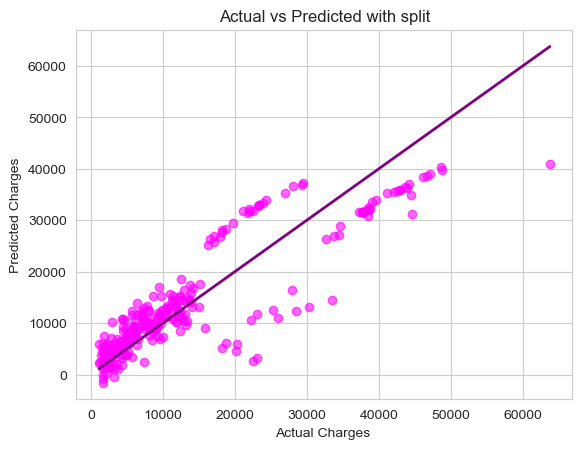

Model score as the R squared: 0.7835929767120722


In [624]:
plt.scatter(y_test, y_pred, color='magenta', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='purple', lw=2) 
plt.xlabel('Actual Charges ')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted with split')
plt.show()
print(f"Model score as the R squared: {regressor.score(x_test, y_test)}")

### Correlation Heatmap

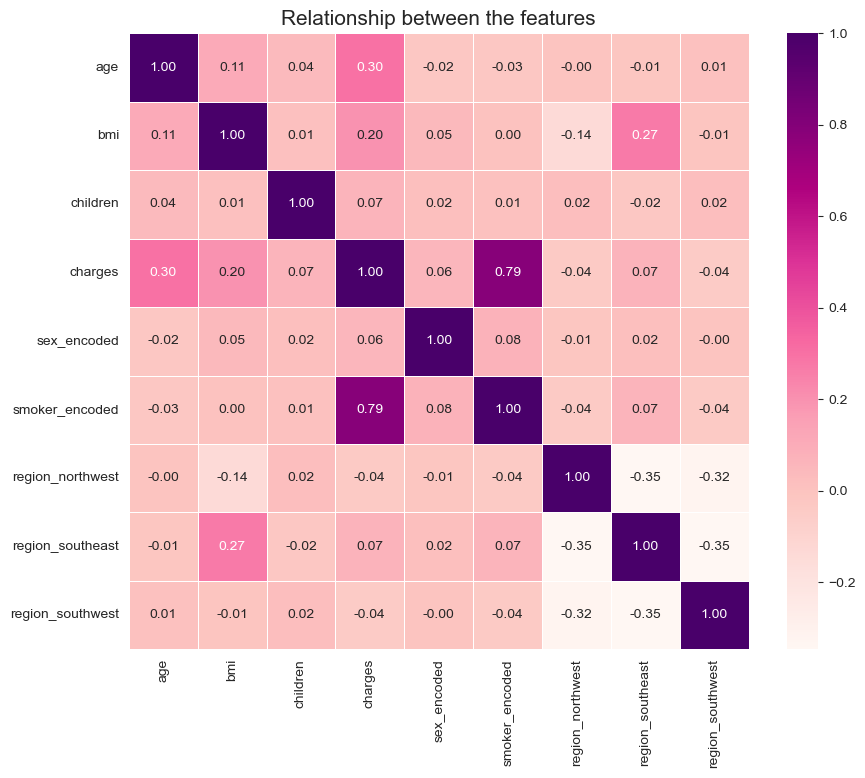

In [625]:
# ompute the correlation matrix

co_mtx = dataset.corr(numeric_only=True)

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_mtx, cmap="RdPu", annot=True, fmt=".2f", linewidths=0.5)

# 
plt.title("Relationship between the features", fontsize=15)
plt.show()

## Final prediction

In [626]:
from sklearn import metrics

# 1. R-Squared
r2 = metrics.r2_score(y_test, y_pred)

# 2. Mean Absolute Error 
mae = metrics.mean_absolute_error(y_test, y_pred)

# 3. Root Mean Squared Error
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print(f"R-Squared Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R-Squared Score: 0.7836
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28
